- Modification for 'Turbustat' versions for sysnthetic:
    - two-dimensional (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_extended.html#turbustat.simulator.make_extended)
    - and three-dimensional fields (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_3dfield.html#make-3dfield)


In [1]:
import time
start_time=time.time()

In [27]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner
import ci_results_compiler


# Add path to py_modules 

sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root


from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot

In [28]:
# Physical parameters

N     = 256
ra    = 32
#ra    = N / 16 # Artificial correlation length
m_obs = 1.0    # The projected slope of the structure function we measure in nature
m2D   = 0.85   # for recovering m as 1.00 in the projected field (k = 2D + m2D) non emissivity fluctuation case
m3D_1 = 0.30   # for recovering m as 1.00 in the projected field (k = 3D + m3D) light fluctuations
m3D_2 = 0.55   # for recovering m as 1.00 in the projected field (k = 3D + m3D) heavy fluctuations
print(ra)

32


From: https://github.com/JavGVastro/PhD.Paper/issues/18

As suggestion from somewhere, the power spectra is in terms of numbers of dimensions (ND) and the N-dimensional slope structure function.

$$\kappa = \text{ND} + m_\text{ND}$$

# Modification

Modification

$$e^{-\dfrac{1}{2 \pi k r_0}}$$


``` python
    if ellip < 1:
        # Apply a rotation and scale the x-axis (ellip).
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        xprime = ellip * (xx * costheta - yy * sintheta)
        yprime = xx * sintheta + yy * costheta

        rr2 = xprime ** 2 + yprime ** 2

        rr = rr2 ** 0.5
        # Also save circular version to use with correlation_length <-----------
        rcirc = np.hypot(xx, yy)   <-----------
        rcirc[rcirc == 0.0] = np.nan  <-----------
    else:
        # Circular whenever ellip == 1
        rr = (xx ** 2 + yy ** 2) ** 0.5

    # flag out the bad point to avoid warnings
    rr[rr == 0] = np.nan

    if correlation_length is not None:     <-----------
        # Taper the power spectrum at large separations (low spatial   <-----------
        # frequencies) so that the field is uncorrelated at the <-----------
        # largest scales. <-----------
        #
        # rcirc is spatial frequency: 1 / r, measured in pixels <-----------
        output *= np.exp(-1.0 / (2 * np.pi * rcirc * correlation_length)) <-----------
```




# Fake velocity fields

In [31]:
# Tapered map
vmap = make_extended(
    N,
    powerlaw           = 2.0 + m2D,
    ellip              = 0.5,
    theta              = 45,
#    cte_length         = 1.0,
    correlation_length = ra,
    randomseed         = 1894_04_25,
)
signorm = vmap.std()
vmap /= signorm


# Non tapered map
vmap0 = make_extended(
    N,
    powerlaw      = 2.0 + m2D,
    ellip         = 0.5,
    theta         = 45,
    randomseed    = 1894_04_25,
)
signorm0 = vmap0.std()
vmap0 /= signorm0

signorm, signorm0

(1.350533652046406, 2.379251535361497)

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_18108\1582354251.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 1.0, '2D Non Tapered')

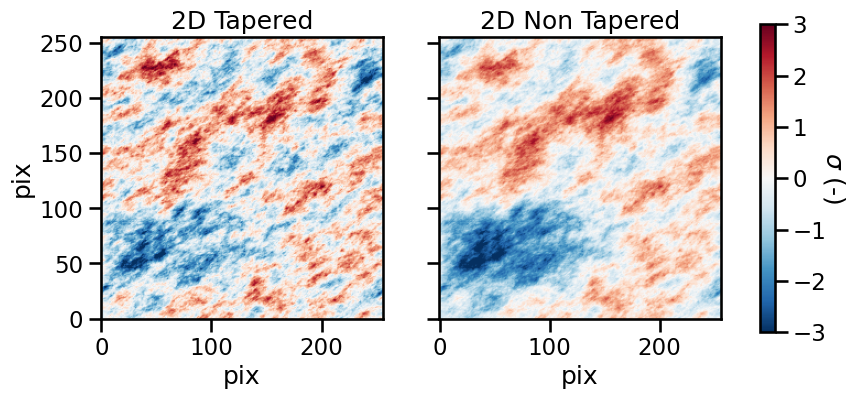

In [32]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap, **imshow_kwds)
im = axx.imshow(vmap0, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax, axx])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")

ax.set_title("2D Tapered")
axx.set_title("2D Non Tapered")